1. Import und Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

2. Daten einlesen

In [31]:
file_path = "../data/cleaned_wlags_Number_of_fires_by_month.csv"
# CSV mit Semikolon-Trenner einlesen
df_fires = pd.read_csv(file_path, sep=",", header=0, encoding="ISO-8859-1")
print(df_fires.columns)


Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')


In [32]:
file_path = "../data/weather_all.csv"
# CSV mit Semikolon-Trenner einlesen
df_weather = pd.read_csv(file_path, sep=",", header=0, encoding="utf-8")
print(df_fires.columns)

Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')





3. Datenbereinigung

In [33]:
# Monat numerisch machen
df_fires["Month"] = pd.to_datetime(df_fires["Month"], format="%B").dt.month

4. Merge data

In [34]:
print(df_fires.columns)
print(df_weather.columns)


Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')
Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'et0_fao_evapotranspiration (mm)',
       'Year', 'Month', 'Jurisdiction'],
      dtype='object')


In [35]:
df_merged = pd.merge(
    df_fires,
    df_weather,
    on=["Year", "Month", "Jurisdiction"],
    how="inner"
)

In [36]:
print(df_merged.columns)
print(df_merged.dtypes)
df_merged.head(10)
print(df_merged.shape)
duplicates = df_merged.duplicated(subset=["Jurisdiction", "Year", "Month"]).sum()
print("Doppelte Schlüssel:", duplicates)
df_merged.isna().sum()

Index(['Jurisdiction', 'Month', 'Year', 'Number_fires',
       'temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'et0_fao_evapotranspiration (mm)'],
      dtype='object')
Jurisdiction                        object
Month                                int32
Year                                 int64
Number_fires                       float64
temperature_2m_mean (°C)           float64
temperature_2m_max (°C)            float64
relative_humidity_2m_mean (%)      float64
relative_humidity_2m_min (%)       float64
precipitation_sum (mm)             float64
precipitation_hours (h)            float64
wind_speed_10m_mean (km/h)         float64
wind_speed_10m_max (km/h)          float64
wind_direction_10m_dominant (°)    float64
et0_fao_evapotranspiratio

Jurisdiction                          0
Month                                 0
Year                                  0
Number_fires                       1264
temperature_2m_mean (°C)              0
temperature_2m_max (°C)               0
relative_humidity_2m_mean (%)         0
relative_humidity_2m_min (%)          0
precipitation_sum (mm)                0
precipitation_hours (h)               0
wind_speed_10m_mean (km/h)            0
wind_speed_10m_max (km/h)             0
wind_direction_10m_dominant (°)       0
et0_fao_evapotranspiration (mm)       0
dtype: int64

5. Korrelationsanalyse

In [37]:
corr_cols = [
    "Number_fires",
    "temperature_2m_mean (°C)",
    "temperature_2m_max (°C)",
    "relative_humidity_2m_mean (%)",
    "relative_humidity_2m_min (%)",
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "wind_speed_10m_mean (km/h)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (°)",
    "et0_fao_evapotranspiration (mm)"
]

df_corr = df_merged[corr_cols].dropna()


In [38]:
pearson_corr = df_corr.corr(method="pearson")
print(pearson_corr)


                                 Number_fires  temperature_2m_mean (°C)  \
Number_fires                         1.000000                  0.373956   
temperature_2m_mean (°C)             0.373956                  1.000000   
temperature_2m_max (°C)              0.421635                  0.992315   
relative_humidity_2m_mean (%)       -0.508568                 -0.220205   
relative_humidity_2m_min (%)        -0.541494                 -0.392718   
precipitation_sum (mm)              -0.068700                  0.379156   
precipitation_hours (h)             -0.169193                  0.051582   
wind_speed_10m_mean (km/h)          -0.294748                 -0.086018   
wind_speed_10m_max (km/h)           -0.257396                 -0.052909   
wind_direction_10m_dominant (°)      0.028698                  0.045077   
et0_fao_evapotranspiration (mm)      0.505967                  0.868344   

                                 temperature_2m_max (°C)  \
Number_fires                           

In [39]:
spearman_corr = df_corr.corr(method="spearman")
print(spearman_corr)


                                 Number_fires  temperature_2m_mean (°C)  \
Number_fires                         1.000000                  0.532235   
temperature_2m_mean (°C)             0.532235                  1.000000   
temperature_2m_max (°C)              0.610296                  0.989962   
relative_humidity_2m_mean (%)       -0.583996                 -0.197204   
relative_humidity_2m_min (%)        -0.719408                 -0.357215   
precipitation_sum (mm)               0.010570                  0.377379   
precipitation_hours (h)             -0.117289                  0.009924   
wind_speed_10m_mean (km/h)          -0.382890                 -0.083607   
wind_speed_10m_max (km/h)           -0.326546                 -0.034807   
wind_direction_10m_dominant (°)     -0.049808                  0.096539   
et0_fao_evapotranspiration (mm)      0.681820                  0.874944   

                                 temperature_2m_max (°C)  \
Number_fires                           

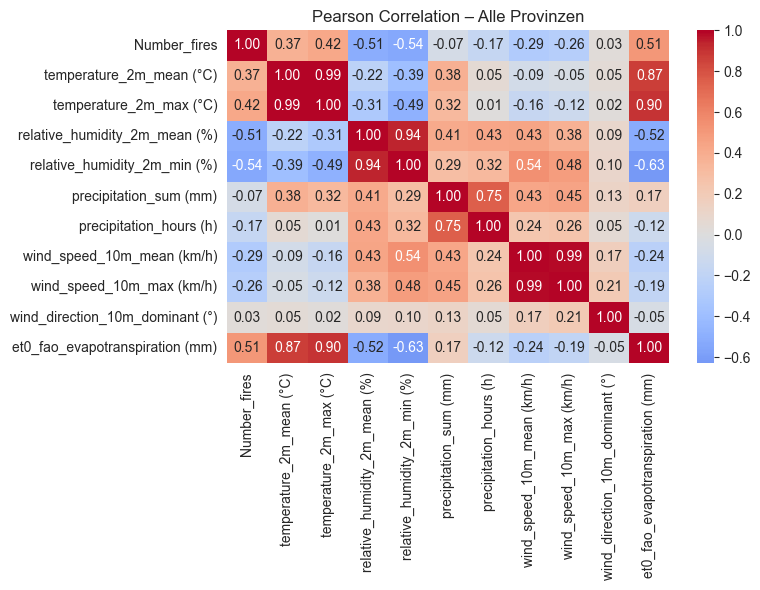

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation – Alle Provinzen")
plt.tight_layout()
plt.show()


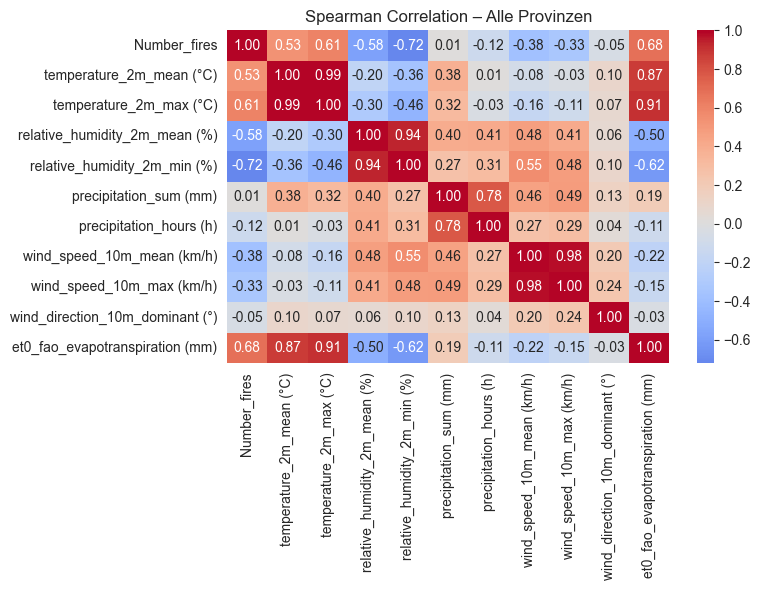

In [41]:
#Spearman heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation – Alle Provinzen")
plt.tight_layout()
plt.show()

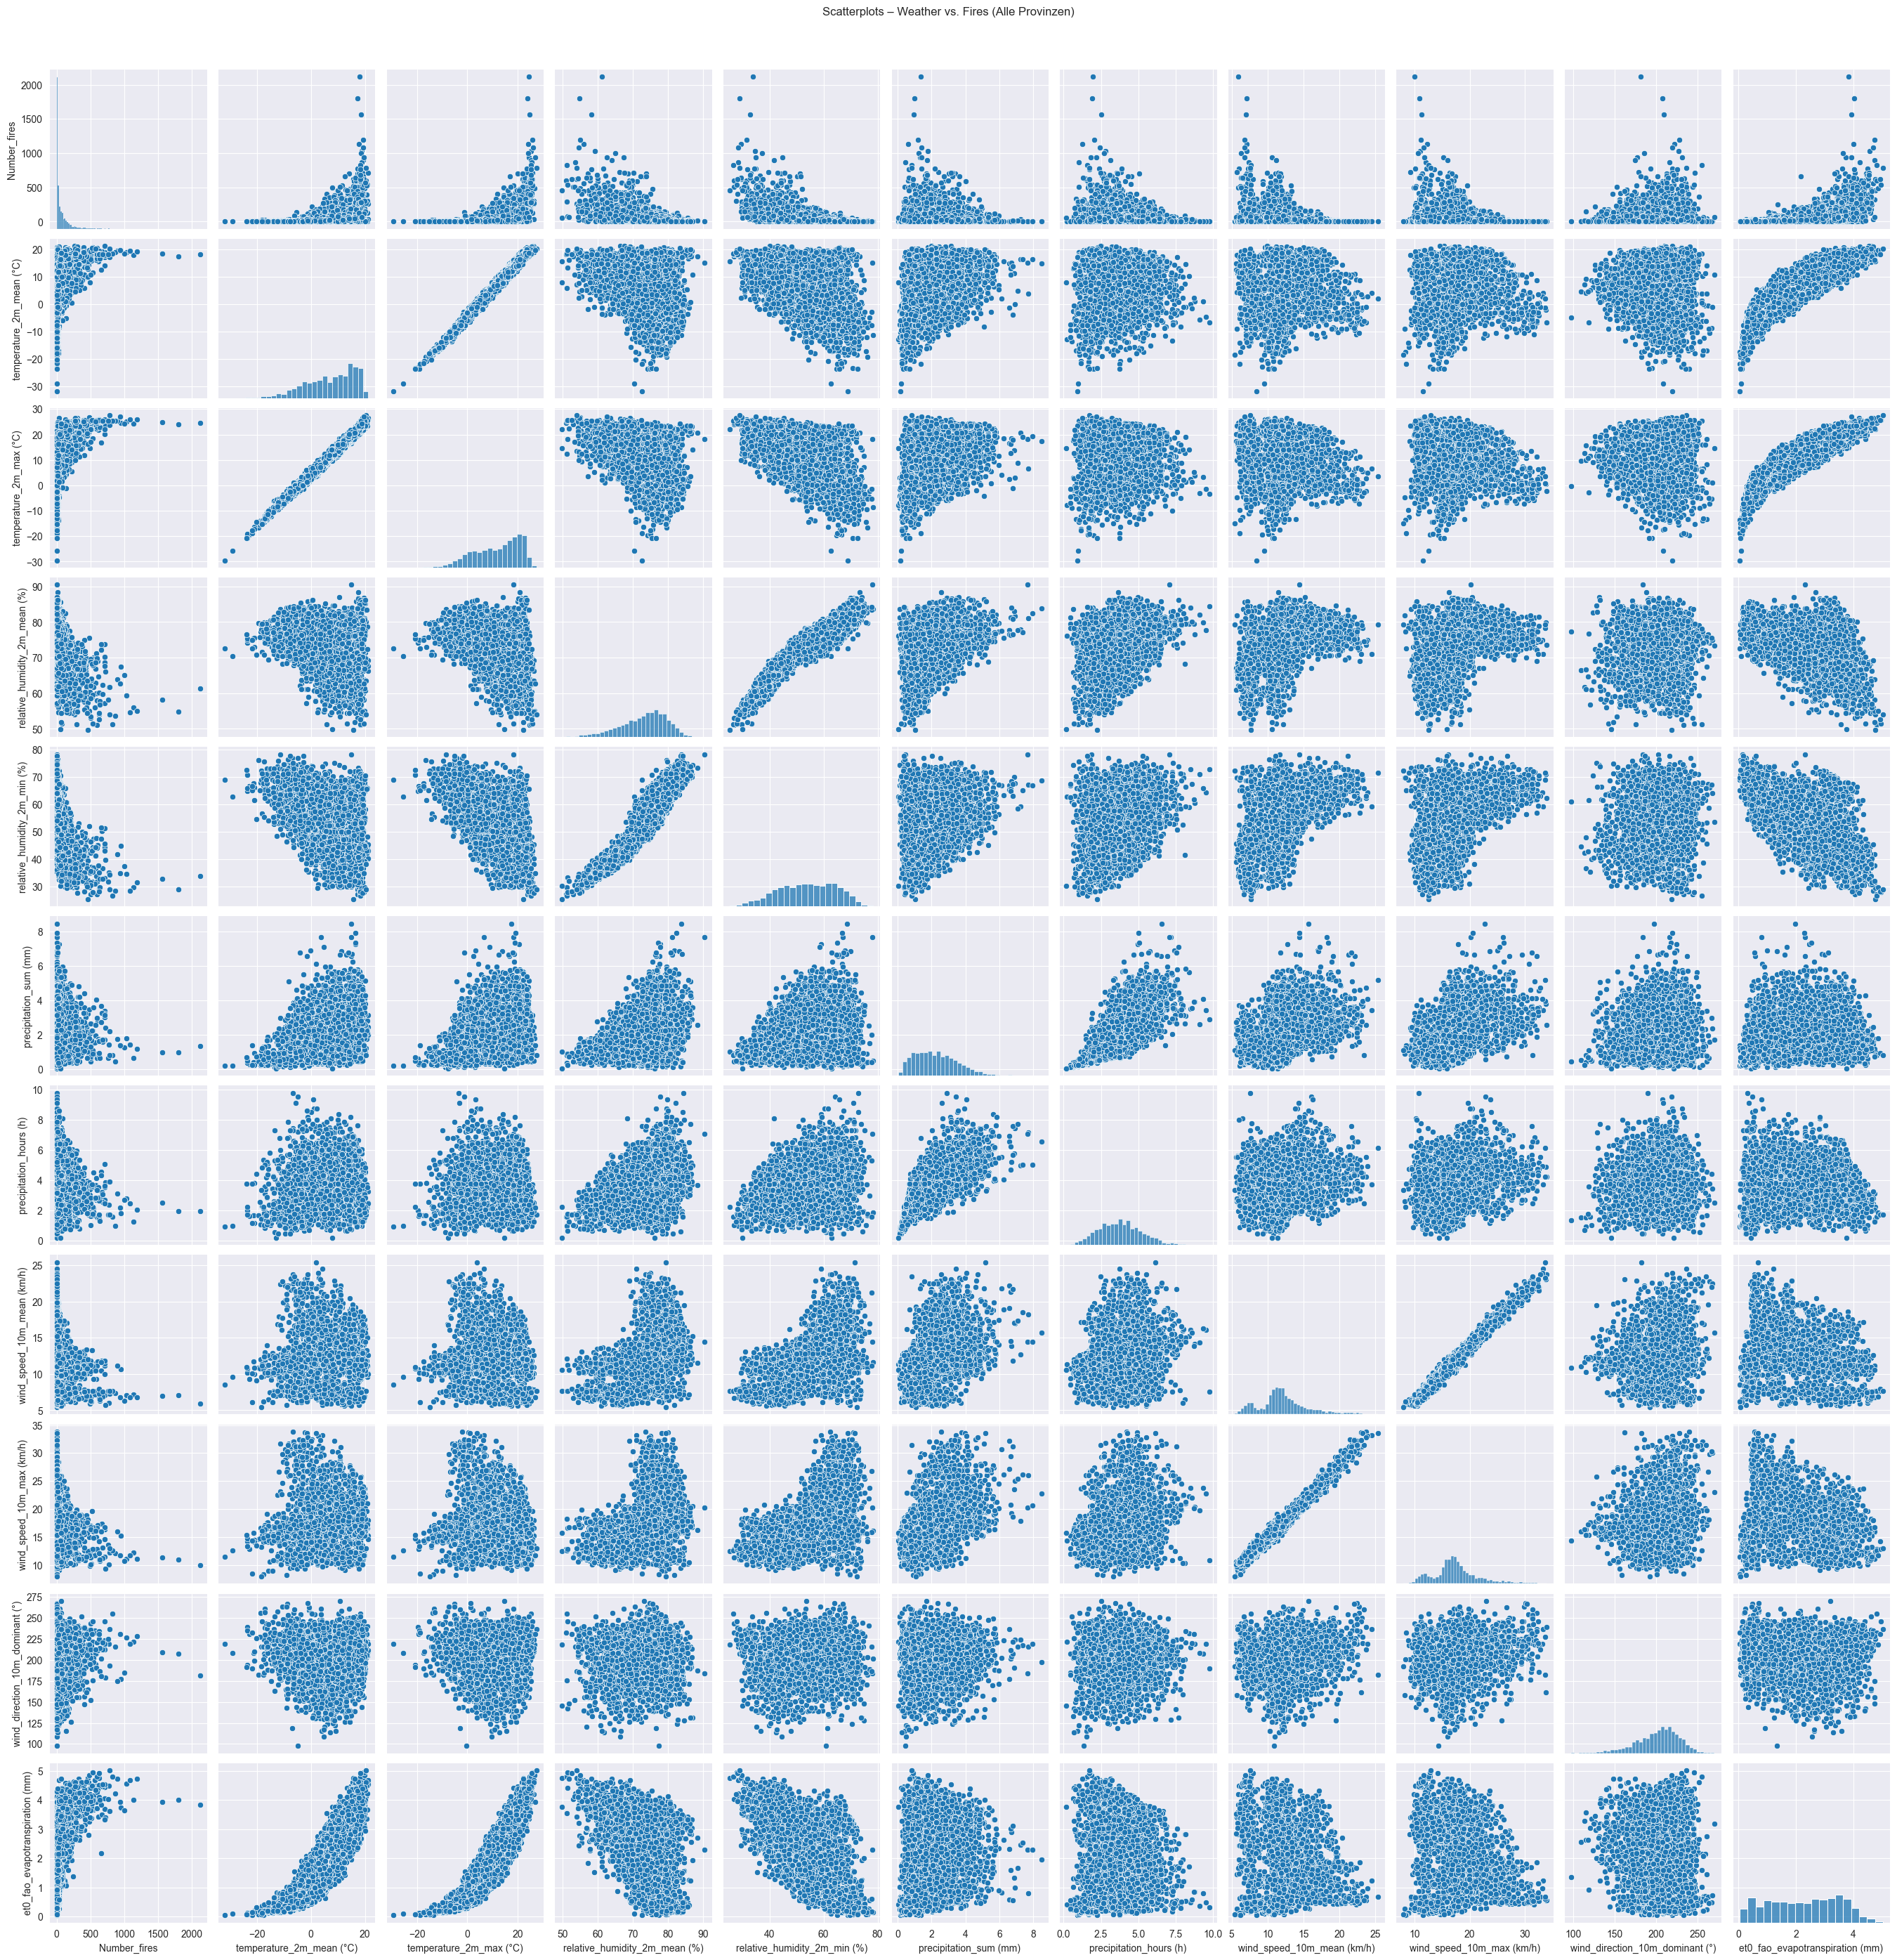

In [42]:
sns.pairplot(
    df_corr,
    kind="scatter",
    diag_kind="hist"
)
plt.suptitle("Scatterplots – Weather vs. Fires (Alle Provinzen)", y=1.02)
plt.show()
